In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf
import scipy.stats as stats
import shap

In [36]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.shape

(1470, 35)

In [37]:
pd.options.display.max_columns = 36
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [38]:
df.shape

(1470, 35)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [40]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [41]:
df=df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)

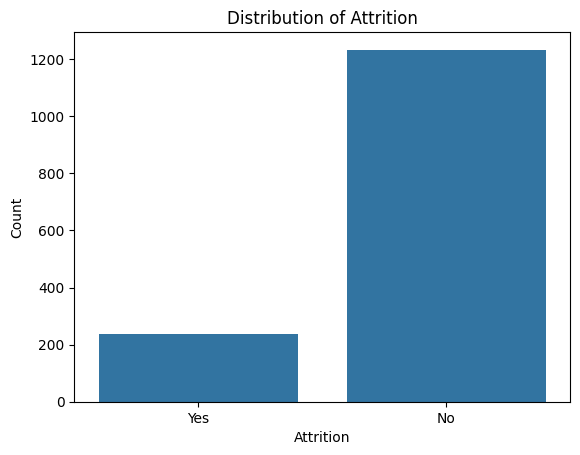

In [42]:
sns.countplot(x='Attrition', data=df)
plt.title('Distribution of Attrition')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

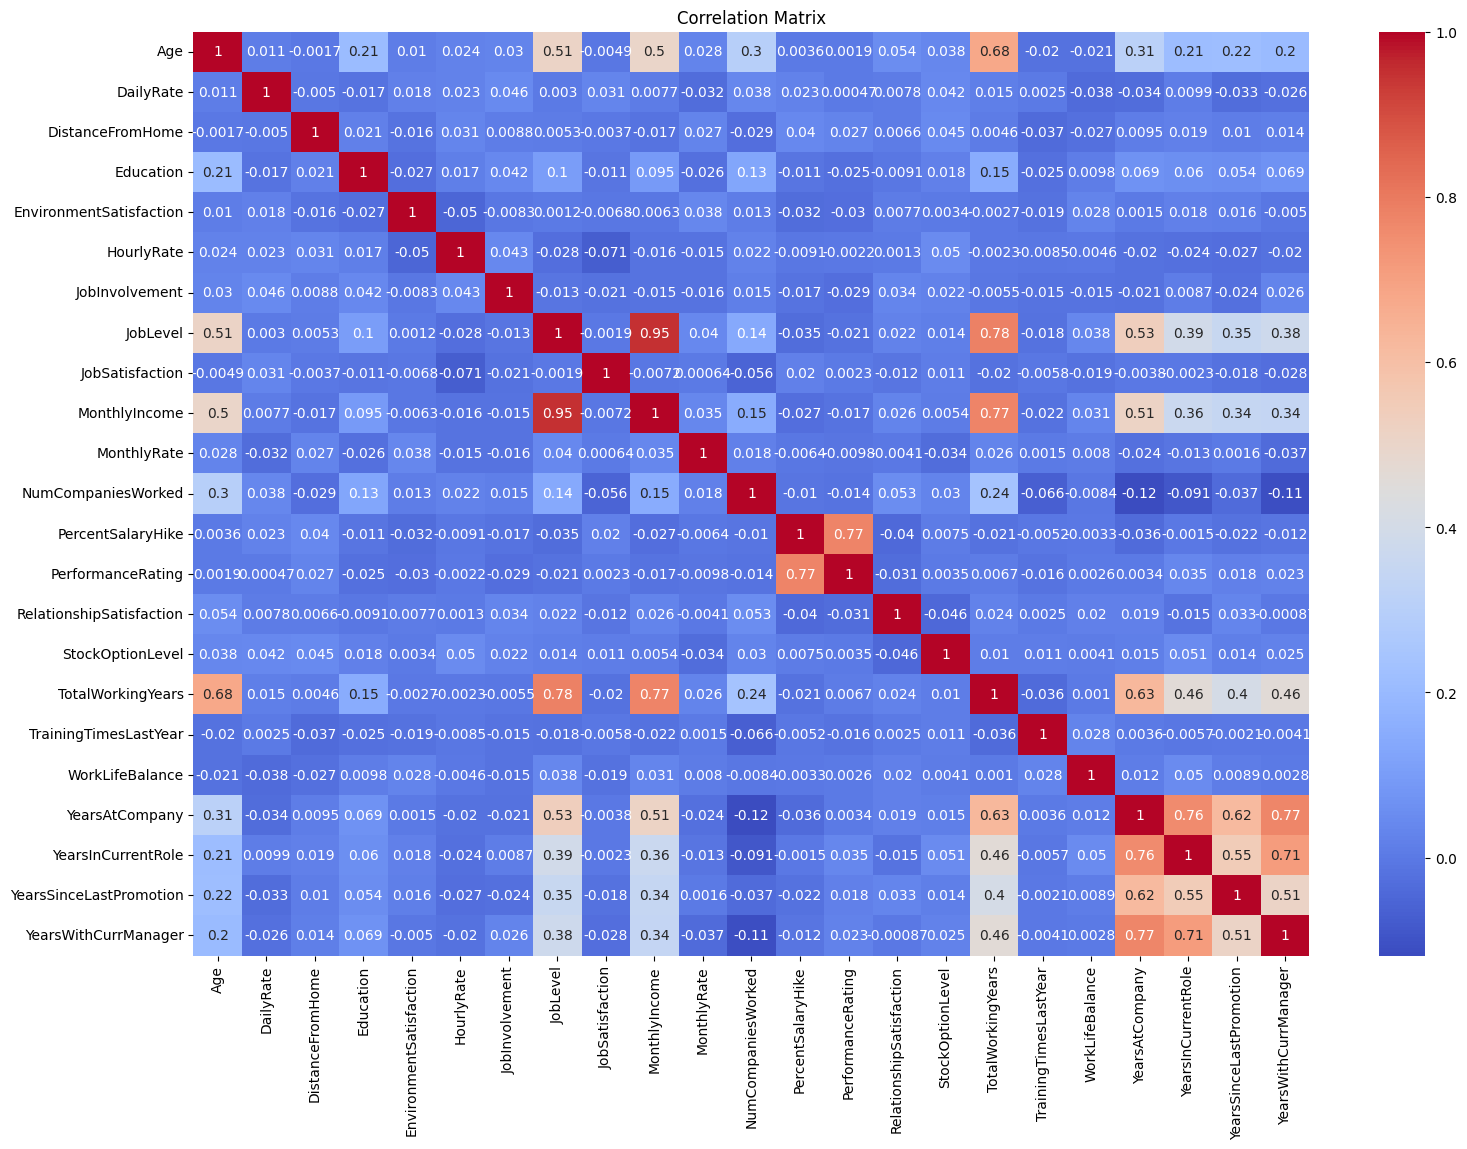

In [43]:
numeric_features = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_features].corr()
plt.figure(figsize=(18, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [44]:
corr_data = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        score = correlation_matrix.iloc[i, j]
        if abs(score) > 0.5:
            rowname = correlation_matrix.index[i]
            colname = correlation_matrix.columns[j]
            corr_data.append({
                'Feature 1': rowname,
                'Feature 2': colname,
                'Correlation': round(score, 2)
            })
high_corr_df = pd.DataFrame(corr_data)
high_corr_df = high_corr_df.sort_values(by='Correlation', ascending=False).reset_index(drop=True)
print(high_corr_df)

                  Feature 1                Feature 2  Correlation
0             MonthlyIncome                 JobLevel         0.95
1         TotalWorkingYears                 JobLevel         0.78
2         PerformanceRating        PercentSalaryHike         0.77
3         TotalWorkingYears            MonthlyIncome         0.77
4      YearsWithCurrManager           YearsAtCompany         0.77
5        YearsInCurrentRole           YearsAtCompany         0.76
6      YearsWithCurrManager       YearsInCurrentRole         0.71
7         TotalWorkingYears                      Age         0.68
8            YearsAtCompany        TotalWorkingYears         0.63
9   YearsSinceLastPromotion           YearsAtCompany         0.62
10  YearsSinceLastPromotion       YearsInCurrentRole         0.55
11           YearsAtCompany                 JobLevel         0.53
12                 JobLevel                      Age         0.51
13           YearsAtCompany            MonthlyIncome         0.51
14     Yea

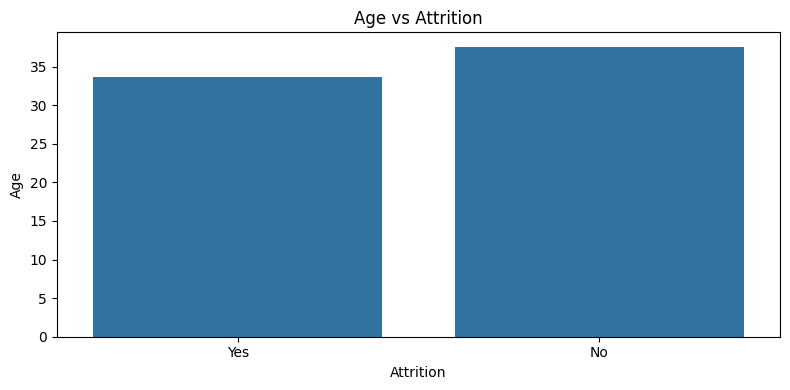

T-test for Age vs Attrition: t-statistic = -5.8280, p-value = 0.0000
there is a significant difference in Age vs Attrition


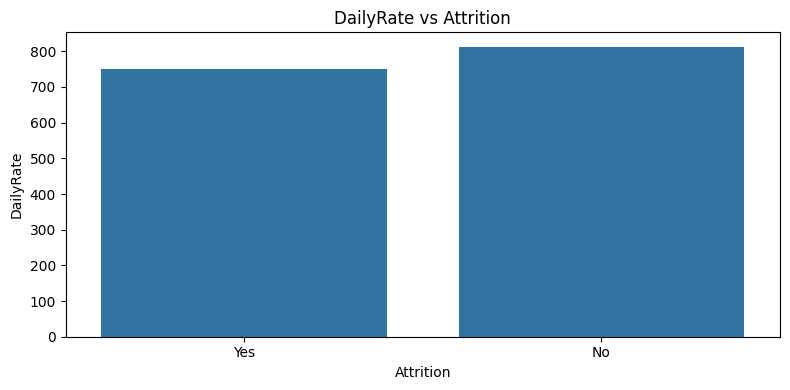

T-test for DailyRate vs Attrition: t-statistic = -2.1789, p-value = 0.0300
there is a significant difference in DailyRate vs Attrition


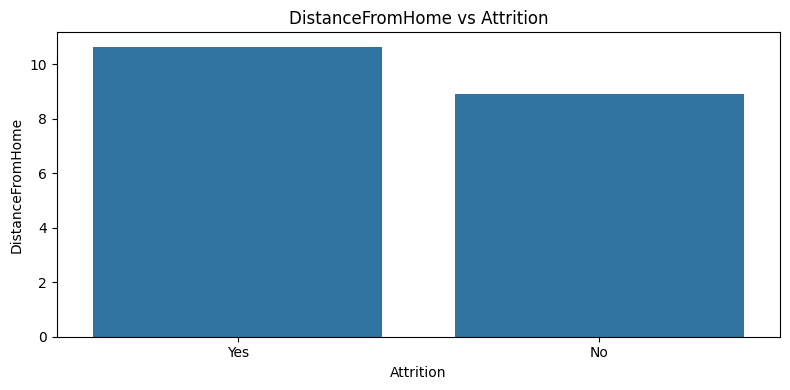

T-test for DistanceFromHome vs Attrition: t-statistic = 2.8882, p-value = 0.0041
there is a significant difference in DistanceFromHome vs Attrition


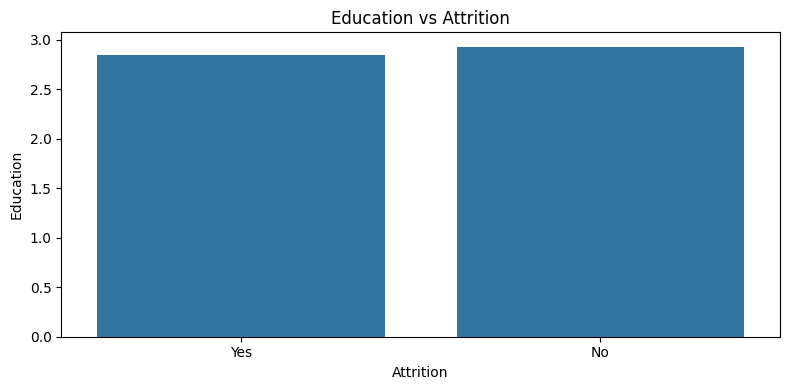

T-test for Education vs Attrition: t-statistic = -1.2177, p-value = 0.2242
there is no significant difference in Education vs Attrition


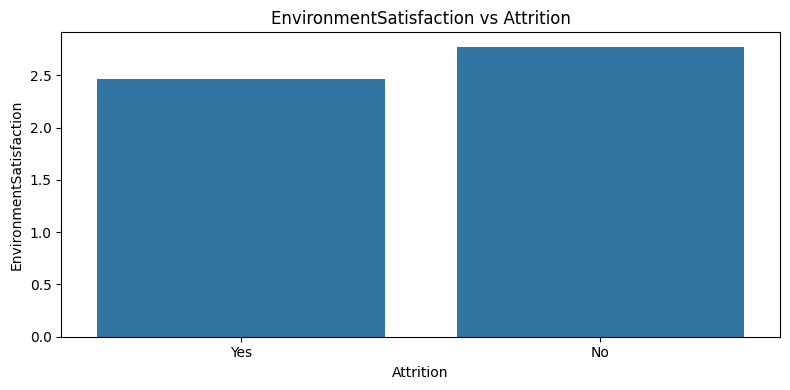

T-test for EnvironmentSatisfaction vs Attrition: t-statistic = -3.7513, p-value = 0.0002
there is a significant difference in EnvironmentSatisfaction vs Attrition


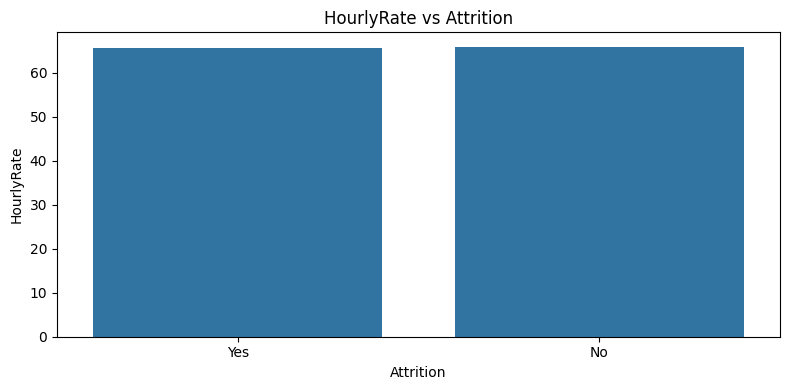

T-test for HourlyRate vs Attrition: t-statistic = -0.2648, p-value = 0.7914
there is no significant difference in HourlyRate vs Attrition


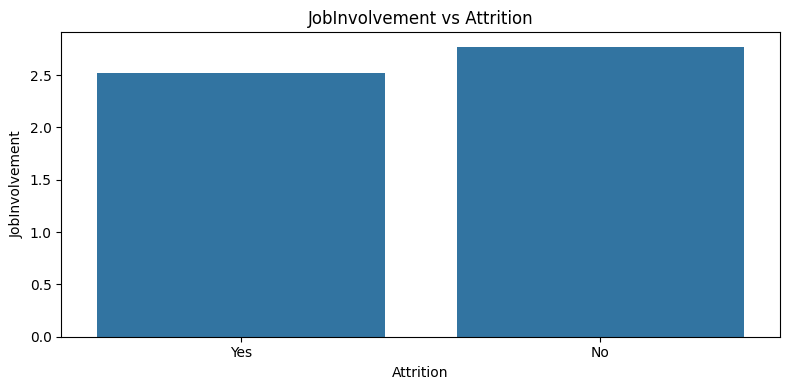

T-test for JobInvolvement vs Attrition: t-statistic = -4.6602, p-value = 0.0000
there is a significant difference in JobInvolvement vs Attrition


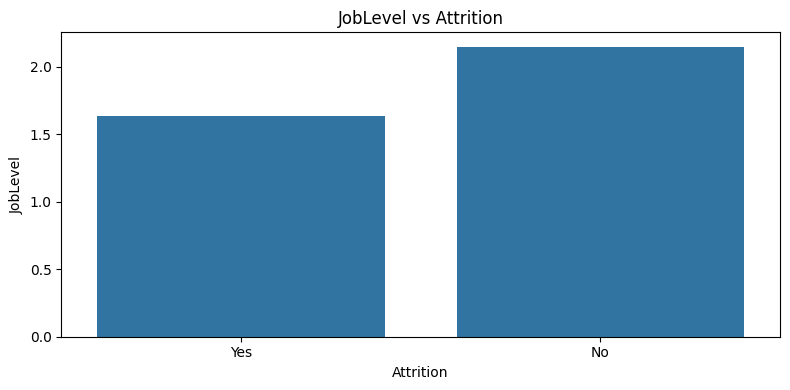

T-test for JobLevel vs Attrition: t-statistic = -7.3859, p-value = 0.0000
there is a significant difference in JobLevel vs Attrition


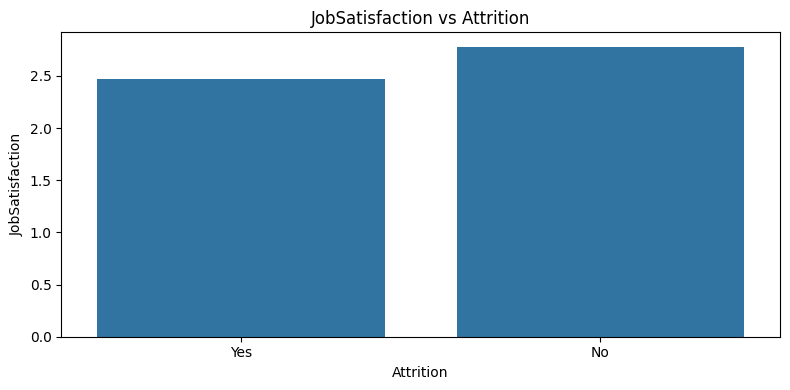

T-test for JobSatisfaction vs Attrition: t-statistic = -3.9261, p-value = 0.0001
there is a significant difference in JobSatisfaction vs Attrition


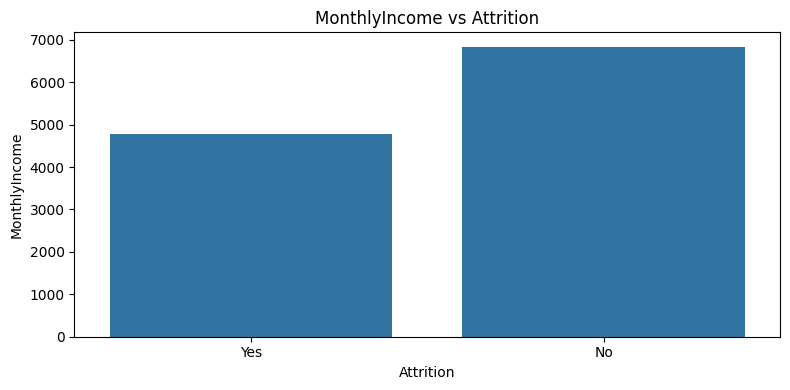

T-test for MonthlyIncome vs Attrition: t-statistic = -7.4826, p-value = 0.0000
there is a significant difference in MonthlyIncome vs Attrition


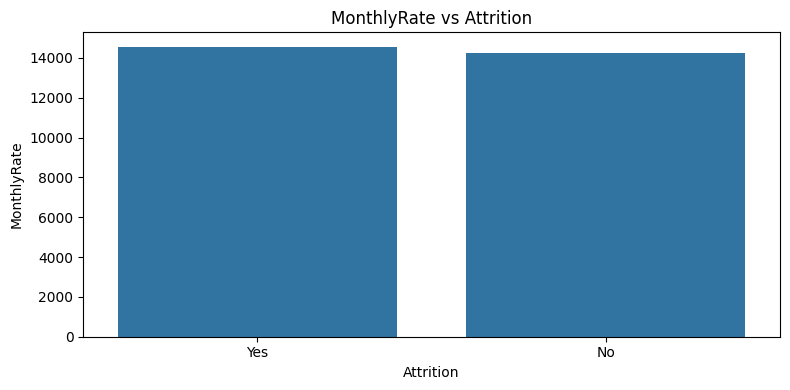

T-test for MonthlyRate vs Attrition: t-statistic = 0.5755, p-value = 0.5653
there is no significant difference in MonthlyRate vs Attrition


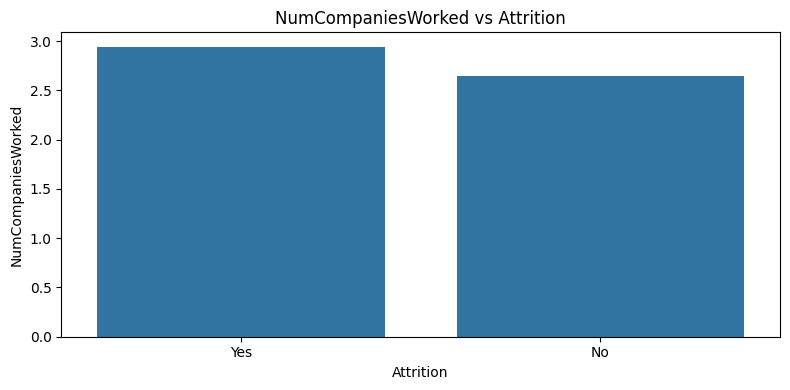

T-test for NumCompaniesWorked vs Attrition: t-statistic = 1.5747, p-value = 0.1163
there is no significant difference in NumCompaniesWorked vs Attrition


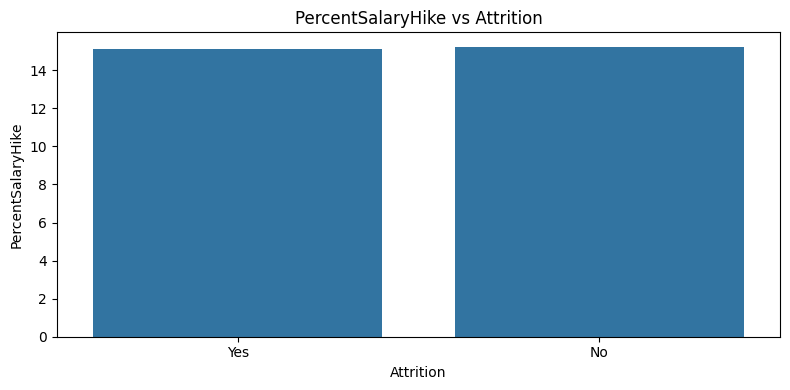

T-test for PercentSalaryHike vs Attrition: t-statistic = -0.5042, p-value = 0.6144
there is no significant difference in PercentSalaryHike vs Attrition


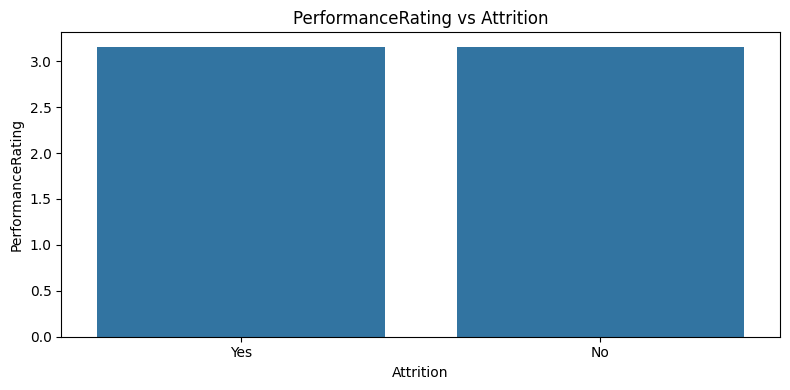

T-test for PerformanceRating vs Attrition: t-statistic = 0.1100, p-value = 0.9125
there is no significant difference in PerformanceRating vs Attrition


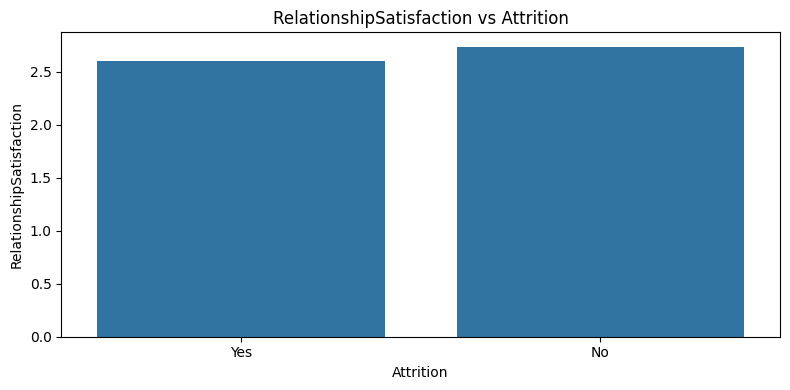

T-test for RelationshipSatisfaction vs Attrition: t-statistic = -1.7019, p-value = 0.0897
there is no significant difference in RelationshipSatisfaction vs Attrition


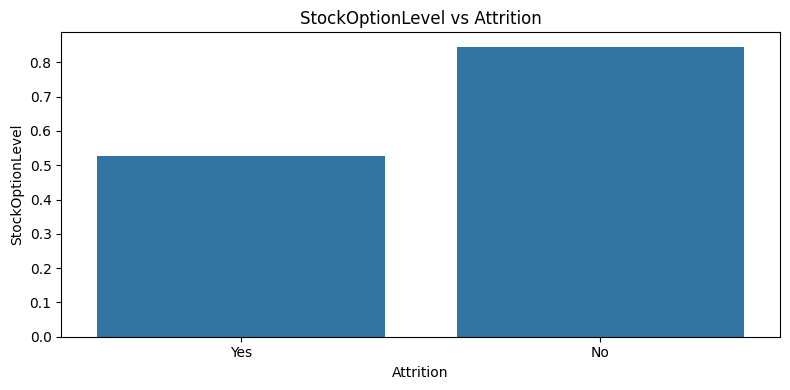

T-test for StockOptionLevel vs Attrition: t-statistic = -5.2442, p-value = 0.0000
there is a significant difference in StockOptionLevel vs Attrition


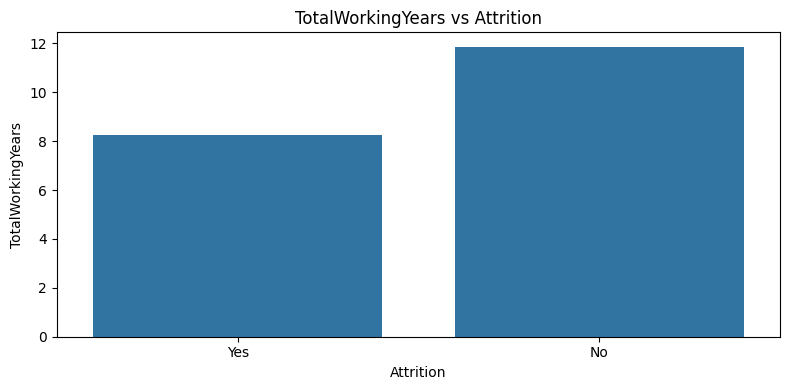

T-test for TotalWorkingYears vs Attrition: t-statistic = -7.0192, p-value = 0.0000
there is a significant difference in TotalWorkingYears vs Attrition


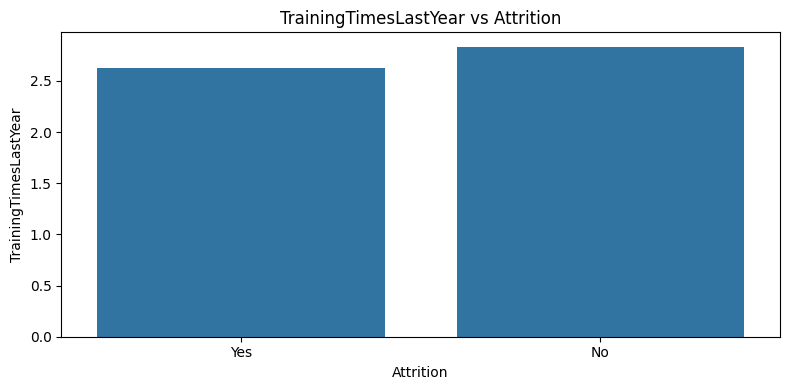

T-test for TrainingTimesLastYear vs Attrition: t-statistic = -2.3305, p-value = 0.0204
there is a significant difference in TrainingTimesLastYear vs Attrition


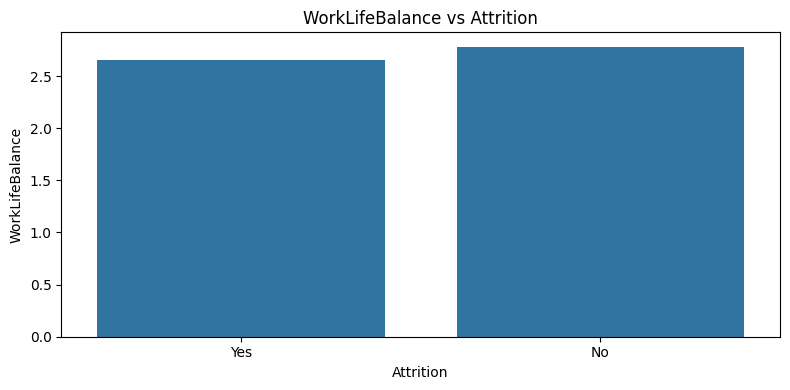

T-test for WorkLifeBalance vs Attrition: t-statistic = -2.1742, p-value = 0.0305
there is a significant difference in WorkLifeBalance vs Attrition


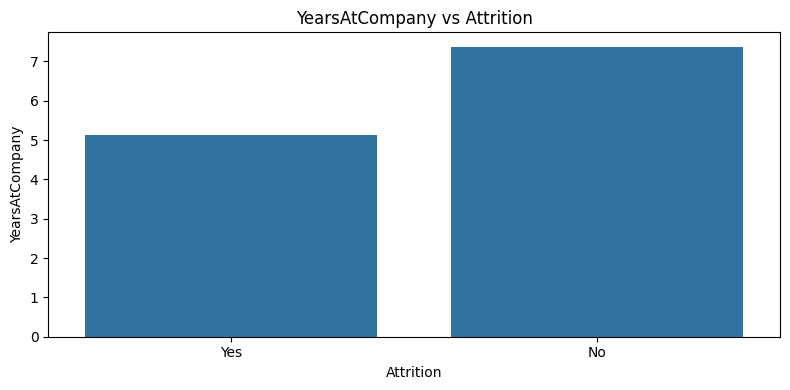

T-test for YearsAtCompany vs Attrition: t-statistic = -5.2826, p-value = 0.0000
there is a significant difference in YearsAtCompany vs Attrition


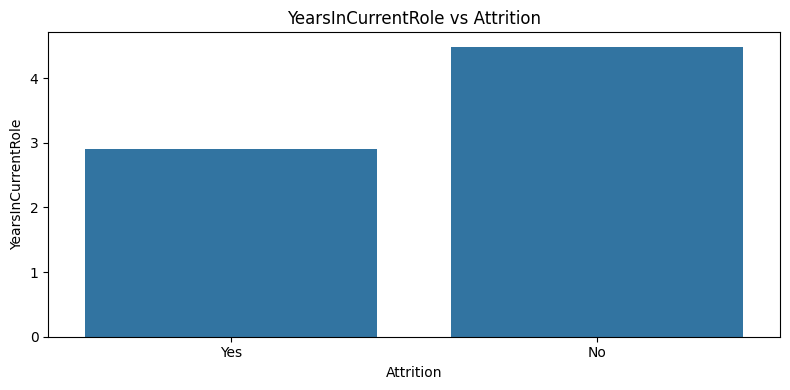

T-test for YearsInCurrentRole vs Attrition: t-statistic = -6.8471, p-value = 0.0000
there is a significant difference in YearsInCurrentRole vs Attrition


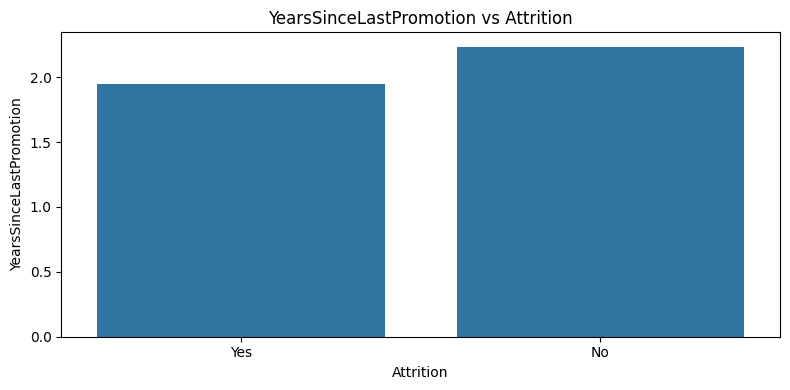

T-test for YearsSinceLastPromotion vs Attrition: t-statistic = -1.2879, p-value = 0.1987
there is no significant difference in YearsSinceLastPromotion vs Attrition


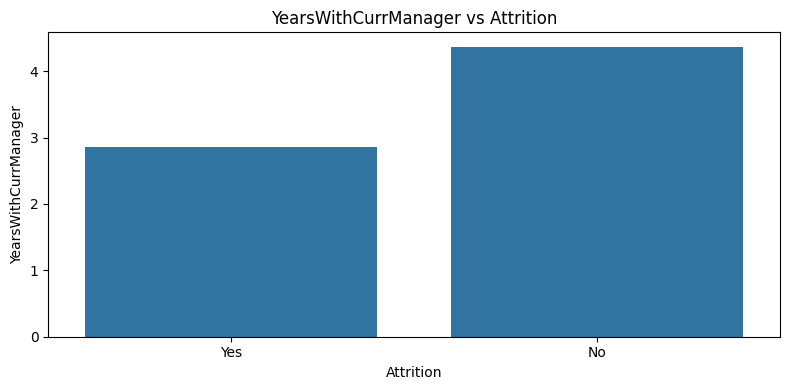

T-test for YearsWithCurrManager vs Attrition: t-statistic = -6.6334, p-value = 0.0000
there is a significant difference in YearsWithCurrManager vs Attrition


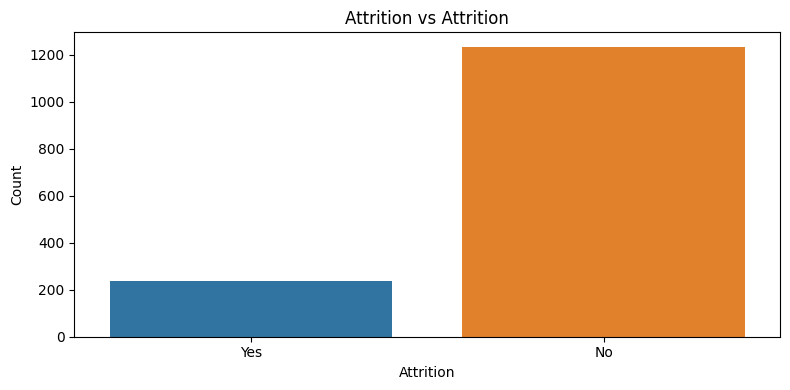

Chi-square test for Attrition vs Attrition: chi2 = 1462.6146, p-value = 0.0000
there is a significant difference in Attrition vs Attrition


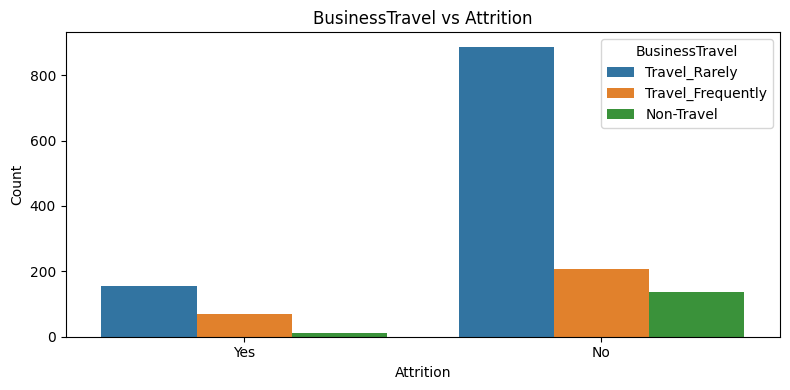

Chi-square test for BusinessTravel vs Attrition: chi2 = 24.1824, p-value = 0.0000
there is a significant difference in BusinessTravel vs Attrition


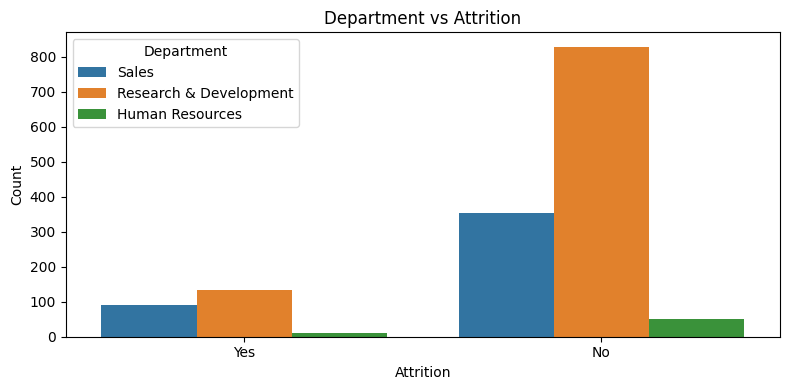

Chi-square test for Department vs Attrition: chi2 = 10.7960, p-value = 0.0045
there is a significant difference in Department vs Attrition


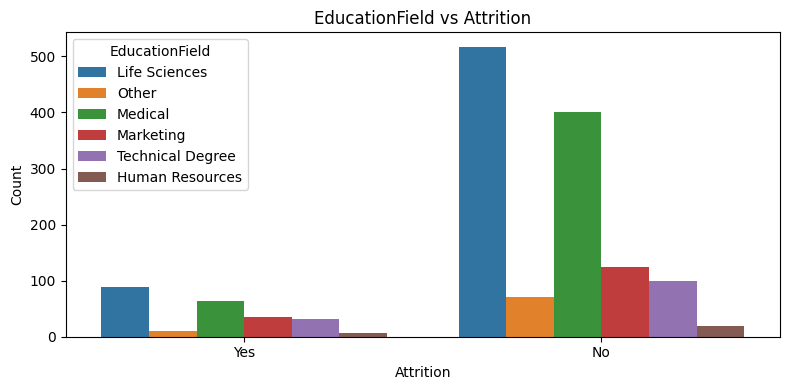

Chi-square test for EducationField vs Attrition: chi2 = 16.0247, p-value = 0.0068
there is a significant difference in EducationField vs Attrition


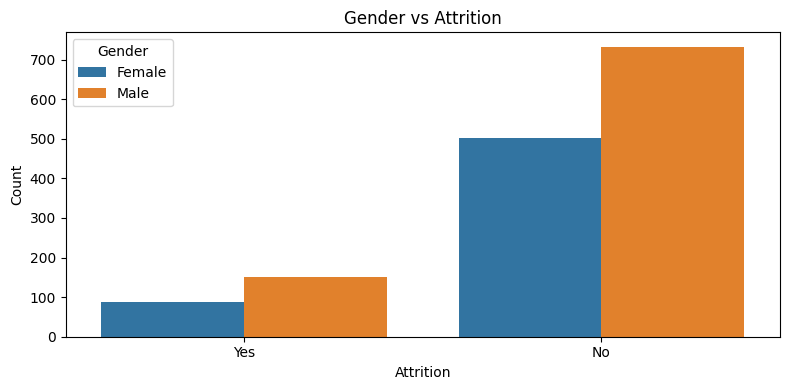

Chi-square test for Gender vs Attrition: chi2 = 1.1170, p-value = 0.2906
there is no significant difference in Gender vs Attrition


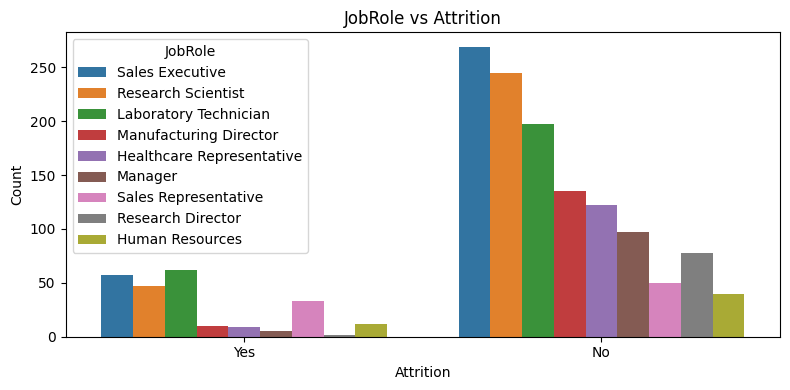

Chi-square test for JobRole vs Attrition: chi2 = 86.1903, p-value = 0.0000
there is a significant difference in JobRole vs Attrition


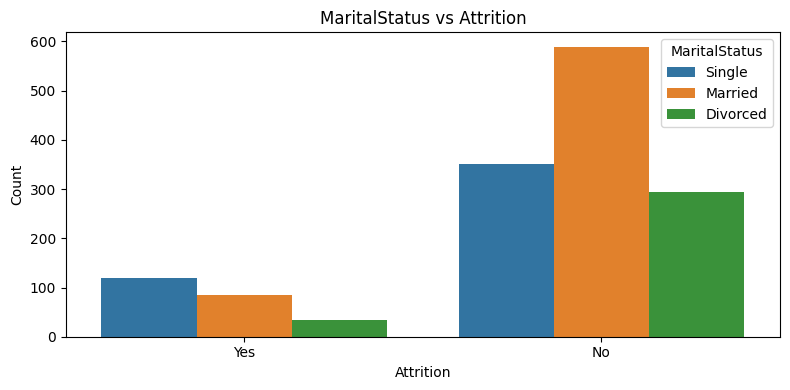

Chi-square test for MaritalStatus vs Attrition: chi2 = 46.1637, p-value = 0.0000
there is a significant difference in MaritalStatus vs Attrition


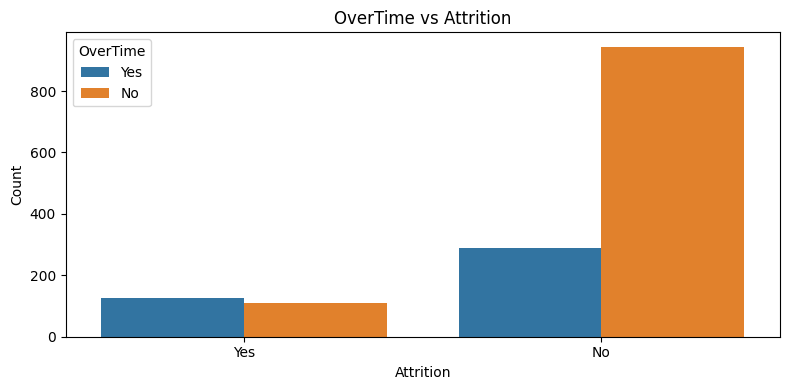

Chi-square test for OverTime vs Attrition: chi2 = 87.5643, p-value = 0.0000
there is a significant difference in OverTime vs Attrition


In [45]:
cat_cols = df.dtypes[df.dtypes == 'object'].index
for num_col in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.barplot(x='Attrition', y=num_col, data=df, errorbar=None)
    plt.title(f'{num_col} vs Attrition')
    plt.xlabel('Attrition')
    plt.ylabel(num_col)
    plt.tight_layout()
    plt.show()
    t_stat, p_value = stats.ttest_ind(
    df[df['Attrition'] == 'Yes'][num_col].dropna(),
    df[df['Attrition'] == 'No'][num_col].dropna(),
    equal_var=False
    )
    print(f'T-test for {num_col} vs Attrition: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}')
    if p_value < 0.05:
      print(f"there is a significant difference in {num_col} vs Attrition")
    else:
      print(f"there is no significant difference in {num_col} vs Attrition")
for cat_col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x='Attrition', hue=cat_col, data=df)
    plt.title(f'{cat_col} vs Attrition')
    plt.xlabel('Attrition')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    contingency_table = pd.crosstab(df['Attrition'], df[cat_col])
    chi2, p_value, _, _ = stats.chi2_contingency(contingency_table)
    print(f'Chi-square test for {cat_col} vs Attrition: chi2 = {chi2:.4f}, p-value = {p_value:.4f}')
    if p_value < 0.05:
     print(f"there is a significant difference in {cat_col} vs Attrition")
    else:
     print(f"there is no significant difference in {cat_col} vs Attrition")

In [47]:
df['years_per_level'] = df['TotalWorkingYears'] / df['JobLevel']


===== Logistic Regression (GridSearch + SMOTE) =====
Accuracy: 0.7551020408163265
Precision: 0.3563218390804598
Recall: 0.6595744680851063
F1: 0.4626865671641791
ROC-AUC: 0.7858558015332933
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



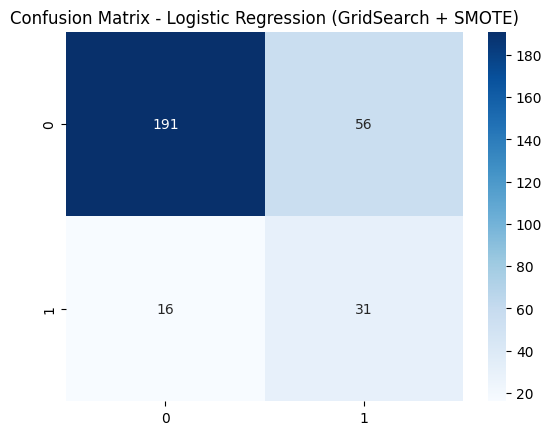

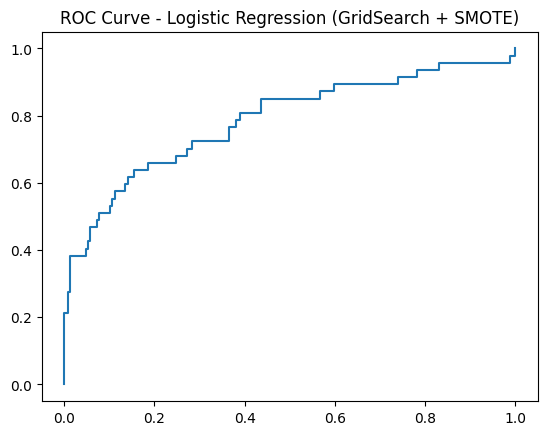


===== Random Forest (GridSearch + SMOTE) =====
Accuracy: 0.826530612244898
Precision: 0.45454545454545453
Recall: 0.425531914893617
F1: 0.43956043956043955
ROC-AUC: 0.7894736842105263
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       247
           1       0.45      0.43      0.44        47

    accuracy                           0.83       294
   macro avg       0.67      0.66      0.67       294
weighted avg       0.82      0.83      0.82       294



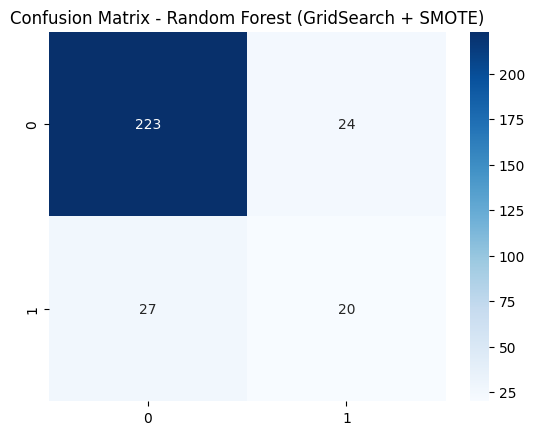

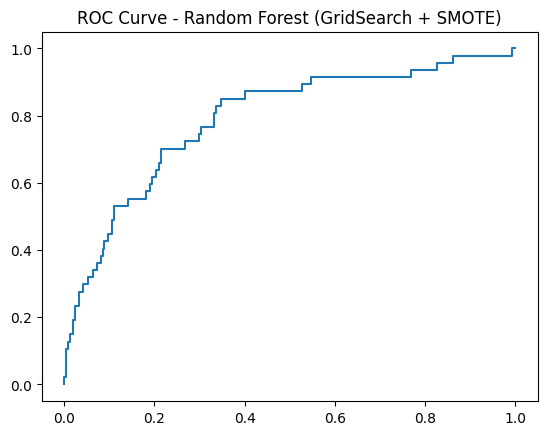


===== XGBoost (GridSearch + SMOTE) =====
Accuracy: 0.8741496598639455
Precision: 0.75
Recall: 0.3191489361702128
F1: 0.44776119402985076
ROC-AUC: 0.7828408993022655
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.75      0.32      0.45        47

    accuracy                           0.87       294
   macro avg       0.82      0.65      0.69       294
weighted avg       0.86      0.87      0.85       294



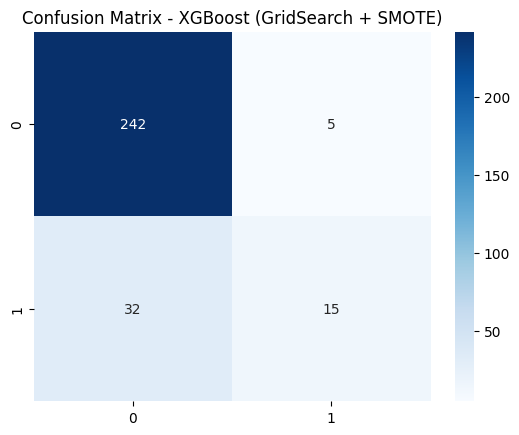

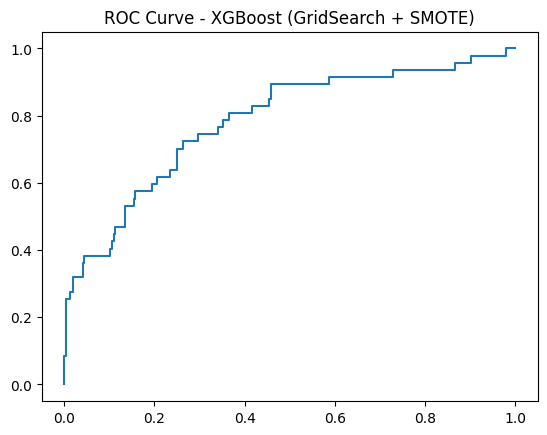

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline 

x = df.drop(['Attrition','JobLevel'], axis=1)
y = df['Attrition'].map({'No': 0, 'Yes': 1})

numeric_features = x.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = x.select_dtypes(include=['object']).columns.tolist()

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


numeric_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, cat_cols)
    ]
)

model_lr = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=2000))
])

model_rf = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

model_xgb = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])


grid_lr = GridSearchCV(
    model_lr,
    param_grid={
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['lbfgs']
    },
    cv=5,
    scoring='f1'
)

grid_rf = GridSearchCV(
    model_rf,
    param_grid={
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [5, 10, None],
        'classifier__min_samples_split': [2, 5],
        'classifier__min_samples_leaf': [1, 2]
    },
    cv=5,
    scoring='f1'
)

grid_xgb = GridSearchCV(
    model_xgb,
    param_grid={
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0]
    },
    cv=5,
    scoring='f1'
)

grid_lr.fit(x_train, y_train)
grid_rf.fit(x_train, y_train)
grid_xgb.fit(x_train, y_train)

best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_
best_xgb = grid_xgb.best_estimator_

def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))

    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr)
    plt.title(f"ROC Curve - {name}")
    plt.show()
    
evaluate(best_lr, x_test, y_test, "Logistic Regression (GridSearch + SMOTE)")
evaluate(best_rf, x_test, y_test, "Random Forest (GridSearch + SMOTE)")
evaluate(best_xgb, x_test, y_test, "XGBoost (GridSearch + SMOTE)")

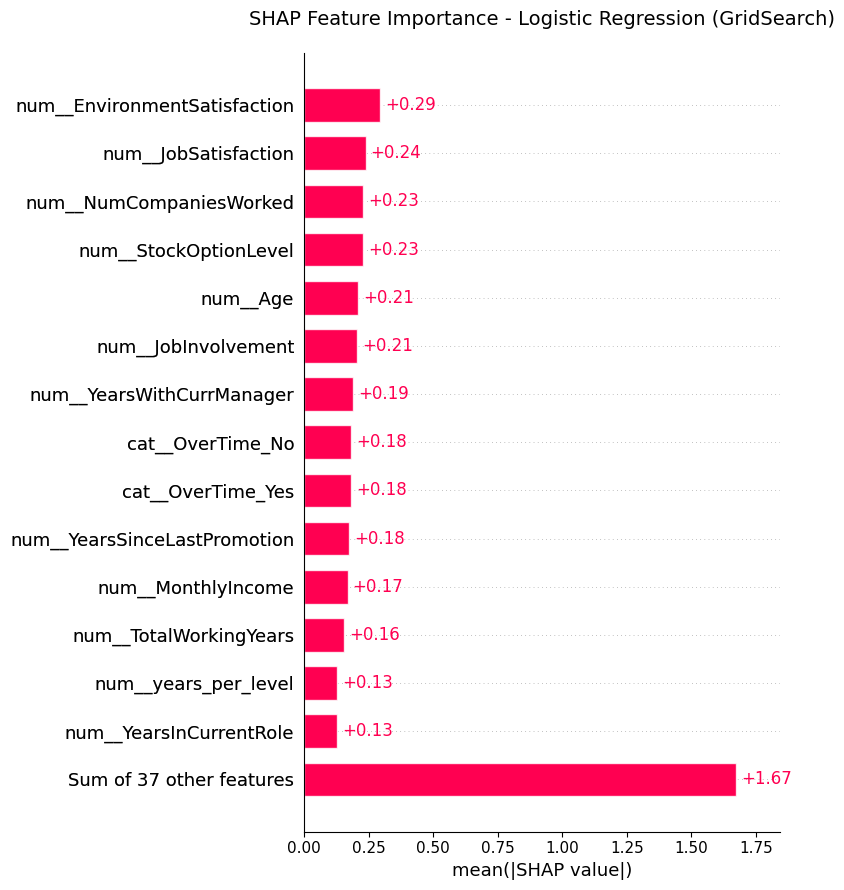

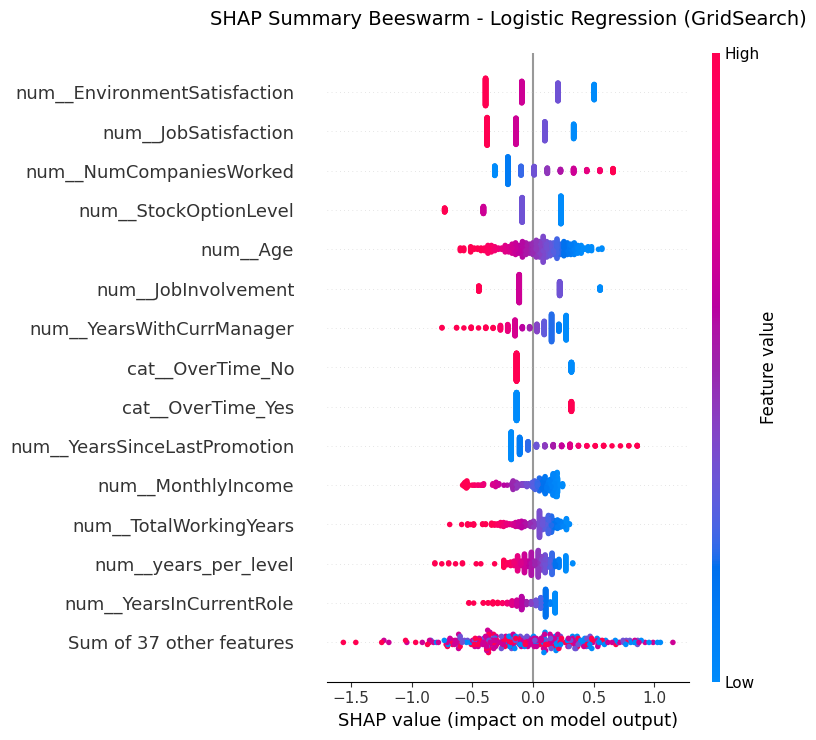

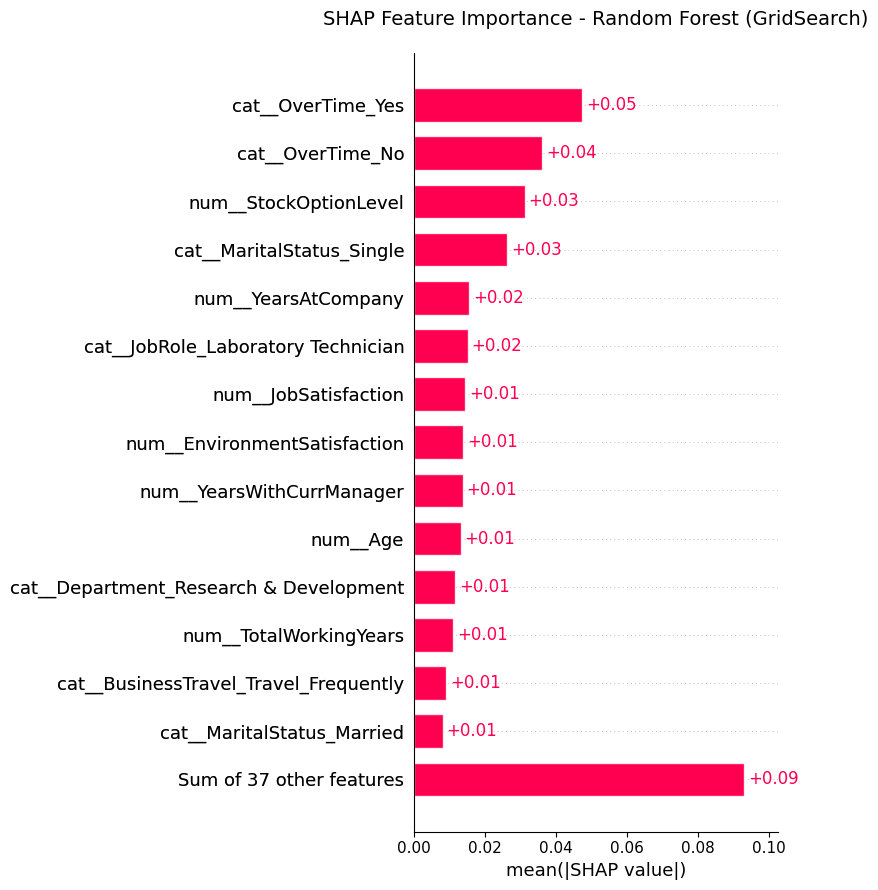

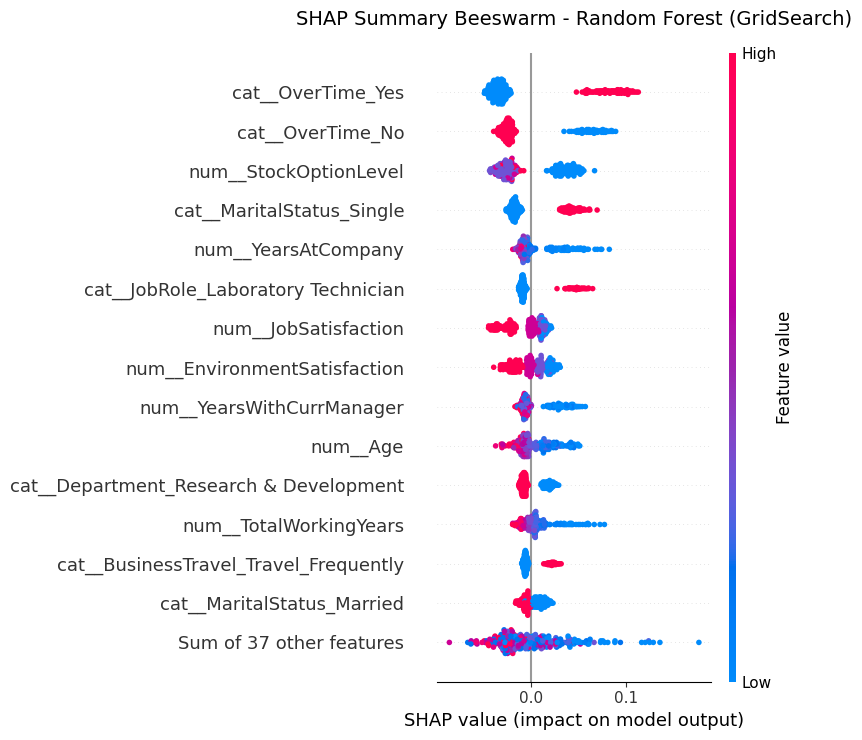

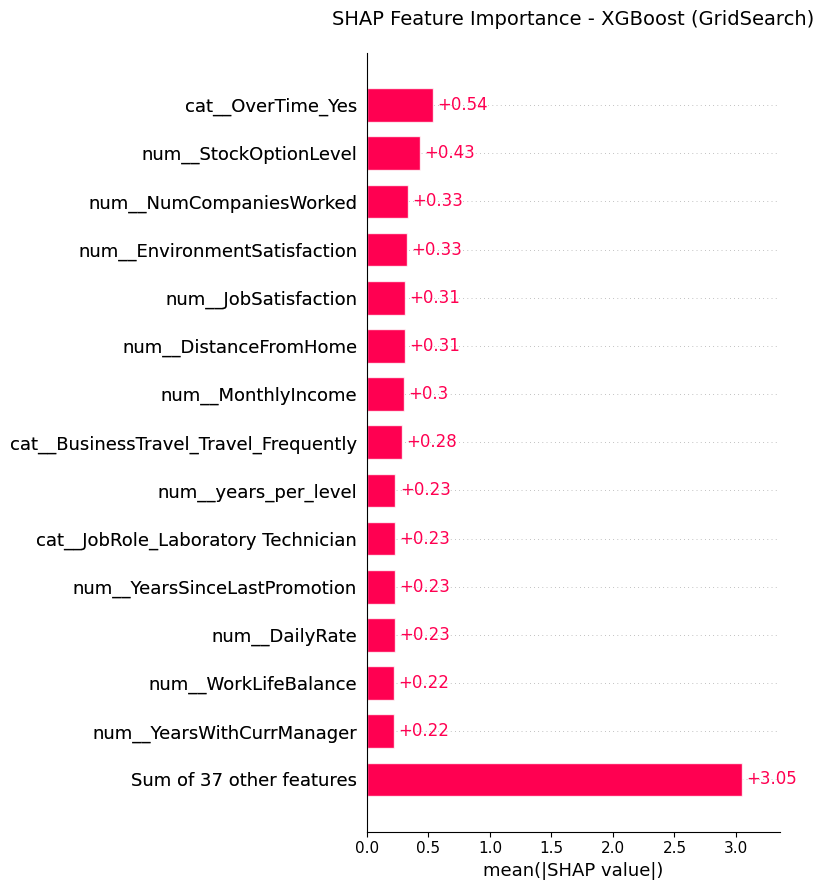

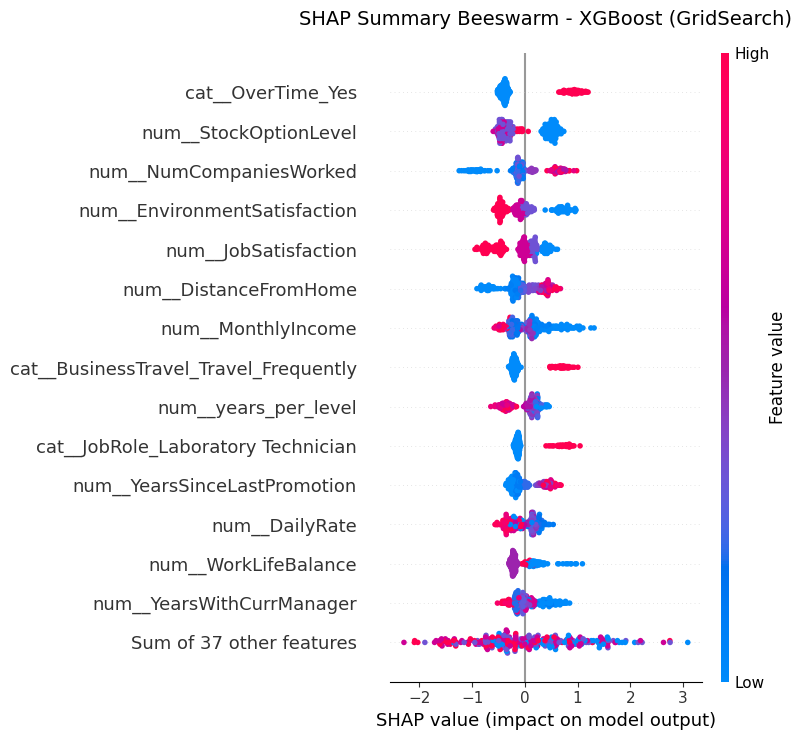

In [49]:
def plot_shap_importance(model_pipeline, x_train, x_test, name):
    preprocessor = model_pipeline.named_steps['preprocessor']
    classifier = model_pipeline.named_steps['classifier']

    
    x_train_transformed = preprocessor.transform(x_train)
    x_test_transformed = preprocessor.transform(x_test)
    feature_names = preprocessor.get_feature_names_out()
    
    if hasattr(x_train_transformed, 'toarray'): 
        x_train_df = pd.DataFrame(x_train_transformed.toarray(), columns=feature_names)
        x_test_df = pd.DataFrame(x_test_transformed.toarray(), columns=feature_names)
    else:
        x_train_df = pd.DataFrame(x_train_transformed, columns=feature_names)
        x_test_df = pd.DataFrame(x_test_transformed, columns=feature_names)

   
    if "Random Forest" in name or "XGBoost" in name:
        
        explainer = shap.Explainer(classifier, x_train_df)
        shap_values = explainer(x_test_df)
        
        
        if len(shap_values.shape) == 3:
            shap_values = shap_values[:, :, 1]
    else:
        
        explainer = shap.LinearExplainer(classifier, x_train_df)
        shap_values = explainer(x_test_df)

    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values, max_display=15, show=False)
    plt.title(f"SHAP Feature Importance - {name}", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
    
   
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_values, max_display=15, show=False)
    plt.title(f"SHAP Summary Beeswarm - {name}", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

plot_shap_importance(best_lr, x_train, x_test, "Logistic Regression (GridSearch)")
plot_shap_importance(best_rf, x_train, x_test, "Random Forest (GridSearch)")
plot_shap_importance(best_xgb, x_train, x_test, "XGBoost (GridSearch)")